### Investigate effect of the loss function

##### 1. Reproduce example presented during the lecture (trade signal)

data shape: (100, 3) 
    Unnamed: 0         X         Y
0           0 -0.015981  0.001984


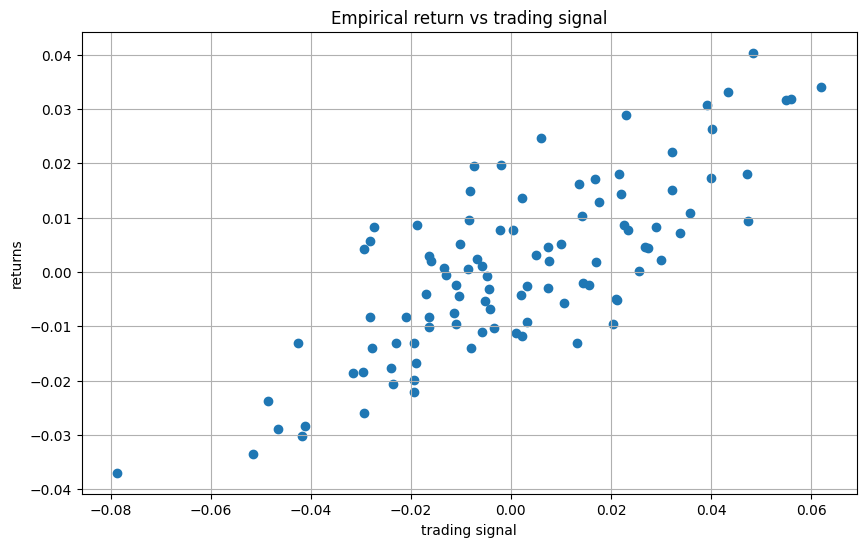

Linear regression result: Y = 0.4688 * X + 0.0002


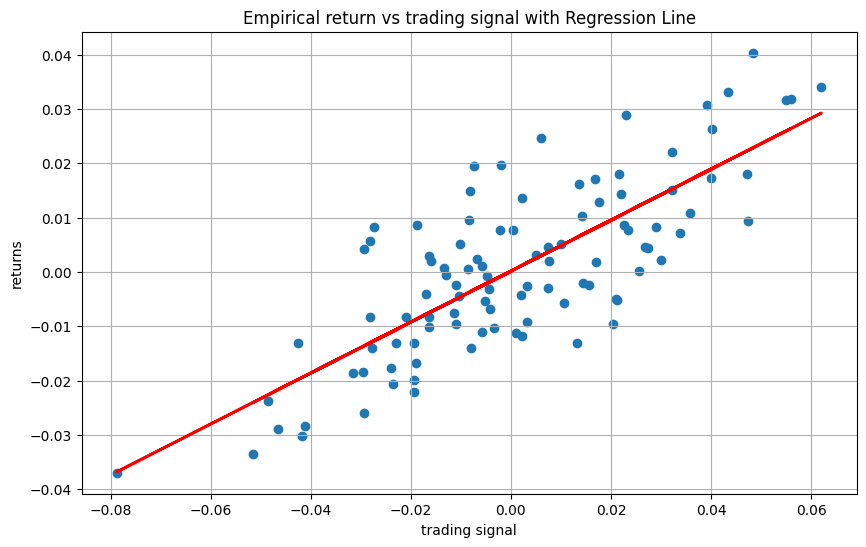

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize

data = pd.read_excel('data_9.xlsx')

print("data shape:", data.shape, '\n', data.head(1))

data = data.iloc[:, -2:]

plt.figure(figsize=(10, 6))
plt.scatter(data['X'], data['Y'])
plt.title('Empirical return vs trading signal')
plt.xlabel('trading signal')    
plt.ylabel('returns')
plt.grid(True)
plt.show()

reg = LinearRegression().fit(data[['X']], data['Y'])
a = reg.coef_[0]
b = reg.intercept_

print(f"Linear regression result: Y = {a:.4f} * X + {b:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(data['X'], data['Y'])
plt.plot(data['X'], reg.predict(data[['X']]), color='red', linewidth=2)
plt.title('Empirical return vs trading signal with Regression Line')
plt.xlabel('trading signal')
plt.ylabel('returns')
plt.grid(True)
plt.show()



##### 2. Check what happens when:


In [ ]:
def stock_loss(factual, predicted, coef = 100.):
    if factual * predicted < 0:
        return coef * predicted**2 + abs(factual - predicted)
    else:
        return abs(factual - predicted)

def fit_with_stock_loss(X, y, coef=100):
    def objective(params):
        a, b = params
        predicted = a * X + b
        mask = y * predicted < 0
        loss = np.abs(y - predicted)
        loss[mask] += coef * predicted[mask]**2
        return np.sum(loss)
    
    result = minimize(objective, [0, 0], method='Nelder-Mead', options={'maxiter': 10000})
    if not result.success:
        print("Warning:", result.message)
    return result.x

 - The quadratic part of the loss function is disabled

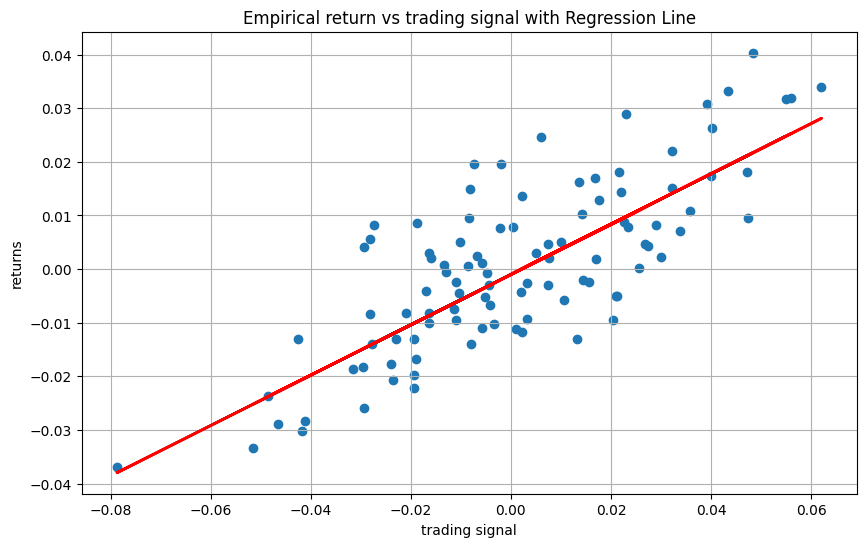

In [30]:
a_stock, b_stock = fit_with_stock_loss(data['X'].values, data['Y'].values, coef=0)

plt.figure(figsize=(10, 6))
plt.scatter(data['X'], data['Y'])
plt.plot(data['X'], a_stock * data['X'] + b_stock, color='red', linewidth=2)
plt.title('Empirical return vs trading signal with Regression Line')
plt.xlabel('trading signal')
plt.ylabel('returns')
plt.grid(True)
plt.show()


- The coefficient by which the quadratic part is multiplied is changed to:
    - 500

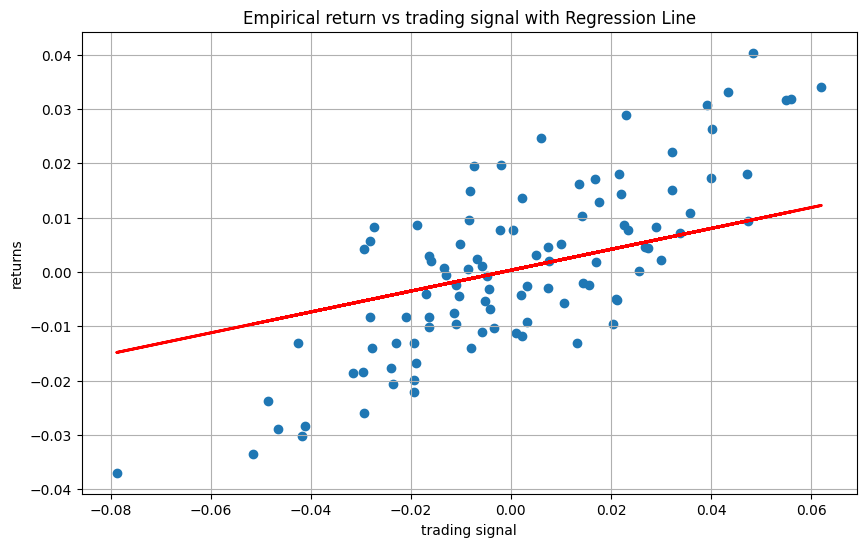

In [31]:
a_stock, b_stock = fit_with_stock_loss(data['X'].values, data['Y'].values, coef=500)

plt.figure(figsize=(10, 6))
plt.scatter(data['X'], data['Y'])
plt.plot(data['X'], a_stock * data['X'] + b_stock, color='red', linewidth=2)
plt.title('Empirical return vs trading signal with Regression Line')
plt.xlabel('trading signal')
plt.ylabel('returns')
plt.grid(True)
plt.show()

- 
    - 1000

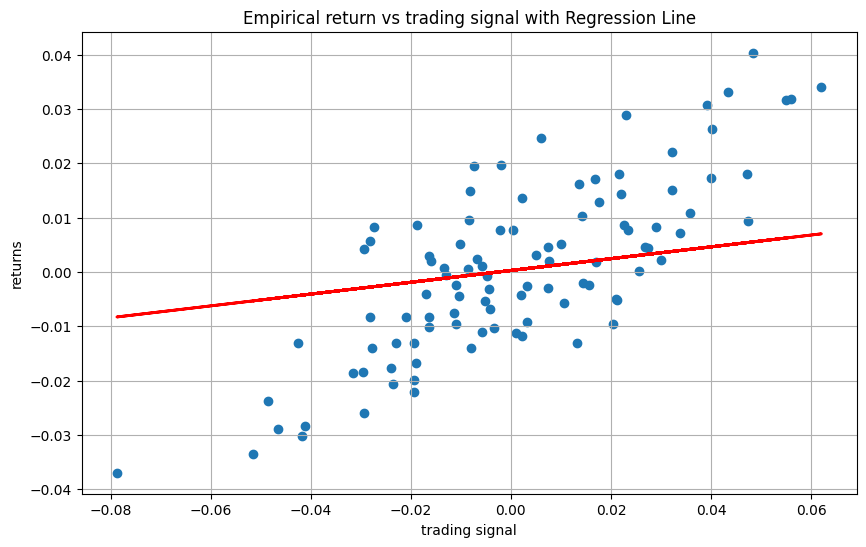

In [32]:
a_stock, b_stock = fit_with_stock_loss(data['X'].values, data['Y'].values, coef=1000)

plt.figure(figsize=(10, 6))
plt.scatter(data['X'], data['Y'])
plt.plot(data['X'], a_stock * data['X'] + b_stock, color='red', linewidth=2)
plt.title('Empirical return vs trading signal with Regression Line')
plt.xlabel('trading signal')
plt.ylabel('returns')
plt.grid(True)
plt.show()